# Crowd-Informed Investing Model

Aggregates sentiment signals from StockTwits, financial news, and price momentum to generate investment scores. Pipeline:

1. **Data Collection** — StockTwits public API (no credentials needed), NewsAPI headlines
2. **Sentiment Analysis** — VADER + finance-specific lexicon, boosted by StockTwits Bullish/Bearish labels
3. **Signal Aggregation** — Engagement-weighted crowd sentiment score per ticker
4. **Price Integration** — yfinance for OHLCV; momentum + sentiment fusion
5. **Scoring & Ranking** — Final composite score with buy/hold/sell signal
6. **Backtest** — Rolling signal accuracy over historical data

## 0. Install Dependencies

In [13]:
# Run once to install required packages
import subprocess, sys

packages = [
    "newsapi-python",
    "vaderSentiment",
    "yfinance",
    "pytrends",        # Google Trends historical crowd-interest proxy
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "requests",
    "scipy",
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("All packages installed.")

## 1. Configuration

In [14]:
import os

# ── StockTwits ──────────────────────────────────────────────────────────────────────────────
NEWSAPI_KEY = os.getenv("NEWSAPI_KEY", "YOUR_NEWSAPI_KEY")

TICKERS = ["AAPL", "MSFT", "NVDA", "TSLA", "GOOGL", "AMZN", "META", "AMD"]

STOCKTWITS_MSG_LIMIT = 300
CRAWL_DELAY_S        = 0.5
NEWS_LOOKBACK_DAYS   = 7
PRICE_LOOKBACK_DAYS  = 90

W_SOCIAL_SENTIMENT  = 0.35
W_NEWS_SENTIMENT    = 0.25
W_MENTION_VELOCITY  = 0.20
W_PRICE_MOMENTUM    = 0.20

BUY_THRESHOLD  =  0.25
SELL_THRESHOLD = -0.25

NEWS_DEMO = (NEWSAPI_KEY == "YOUR_NEWSAPI_KEY")
print(f"StockTwits: live (no credentials needed)")
print(f"News demo mode: {NEWS_DEMO}  → set NEWSAPI_KEY env var for live news")

StockTwits: live (no credentials needed)
News demo mode: True  → set NEWSAPI_KEY env var for live news


## 2. Data Collection

In [15]:
import requests
from newsapi import NewsApiClient
from datetime import datetime, timedelta
import pandas as pd
import re
import time

_ticker_pattern = re.compile(
    r"\\b(" + "|".join(re.escape(t) for t in TICKERS) + r")\\b"
)

def extract_tickers(text):
    return list(set(_ticker_pattern.findall(text.upper())))

_ST_HEADERS = {"User-Agent": "crowd_investing_model/0.1 (research)"}

def fetch_social_posts(limit=STOCKTWITS_MSG_LIMIT):
    """Fetch StockTwits messages for each ticker. No API key needed."""
    rows = []
    msgs_per_ticker = max(limit // len(TICKERS), 10)

    for ticker in TICKERS:
        print(f"  Fetching ${ticker}...", end=" ", flush=True)
        collected = 0
        max_id    = None

        while collected < msgs_per_ticker:
            params = {"limit": min(30, msgs_per_ticker - collected)}
            if max_id:
                params["max"] = max_id
            try:
                resp = requests.get(
                    f"https://api.stocktwits.com/api/2/streams/symbol/{ticker}.json",
                    headers=_ST_HEADERS, params=params, timeout=10,
                )
                resp.raise_for_status()
                messages = resp.json().get("messages", [])
            except Exception as e:
                print(f"\n    Warning: {e}")
                break
            if not messages:
                break
            for msg in messages:
                if collected >= msgs_per_ticker:
                    break
                body      = msg.get("body", "")
                entities  = msg.get("entities") or {}
                sentiment = entities.get("sentiment") or {}
                label     = sentiment.get("basic", "")
                likes     = (msg.get("likes") or {}).get("total", 0)
                if label == "Bullish":
                    upvote_ratio = 0.95
                elif label == "Bearish":
                    upvote_ratio = 0.20
                else:
                    upvote_ratio = 0.72
                rows.append({
                    "source":       "stocktwits",
                    "subreddit":    "stocktwits",
                    "ticker":       ticker,
                    "text":         body,
                    "score":        max(likes, 1),
                    "comments":     0,
                    "upvote_ratio": upvote_ratio,
                    "created_utc":  pd.to_datetime(msg.get("created_at"), utc=True),
                    "label":        label,
                })
                collected += 1
            max_id = messages[-1]["id"]
            time.sleep(CRAWL_DELAY_S)
        print(f"{collected} messages")

    print(f"  Collected {len(rows)} total messages")
    if not rows:
        print("  No data -- falling back to demo data")
        return _demo_social_posts()
    return pd.DataFrame(rows)


def fetch_news_articles():
    """Fetch news headlines for each ticker via NewsAPI."""
    if NEWS_DEMO:
        return _demo_news_articles()
    newsapi   = NewsApiClient(api_key=NEWSAPI_KEY)
    from_date = (datetime.now() - timedelta(days=NEWS_LOOKBACK_DAYS)).strftime("%Y-%m-%d")
    rows      = []
    name_map  = {
        "AAPL": "Apple", "MSFT": "Microsoft", "NVDA": "Nvidia",
        "TSLA": "Tesla",  "GOOGL": "Google",   "AMZN": "Amazon",
        "META": "Meta",   "AMD": "AMD",
    }
    for ticker in TICKERS:
        query = f"{ticker} OR {name_map.get(ticker, ticker)} stock"
        try:
            resp = newsapi.get_everything(
                q=query, language="en", from_param=from_date,
                sort_by="relevancy", page_size=20,
            )
            for art in resp.get("articles", []):
                rows.append({
                    "source":       "news",
                    "outlet":       art["source"]["name"],
                    "ticker":       ticker,
                    "text":         (art["title"] or "") + " " + (art["description"] or ""),
                    "score":        1,
                    "published_at": pd.to_datetime(art["publishedAt"]),
                })
        except Exception as e:
            print(f"NewsAPI error for {ticker}: {e}")
        time.sleep(0.3)
    return pd.DataFrame(rows)


print("Data collection functions ready.")

Data collection functions ready.


In [16]:
import numpy as np
import random

random.seed(42)
np.random.seed(42)

DEMO_SOCIAL_TEMPLATES = [
    "{t} is going to the moon! Loaded up on calls.",
    "Anyone else holding {t}? Earnings beat was massive.",
    "DD: Why {t} is massively undervalued right now",
    "Sold all my {t} -- the fundamentals don't support this valuation",
    "{t} just announced a stock buyback. Bullish.",
    "Is {t} a value trap? Revenue growth is slowing.",
    "{t} short squeeze incoming. Short interest at 20%.",
    "Why I'm bearish on {t} for the next quarter",
    "{t} just hit ATH. Is it too late to buy?",
    "Averaging down on {t}. Long-term conviction unchanged.",
]

DEMO_NEWS_TEMPLATES = [
    "{company} reports record quarterly earnings, shares rise",
    "{company} faces regulatory scrutiny in EU antitrust probe",
    "{company} announces $10B share buyback program",
    "Analysts upgrade {company} to Buy with raised price target",
    "{company} misses revenue estimates for the second straight quarter",
    "{company} CEO signals strong guidance for next fiscal year",
    "Hedge funds increase positions in {company}",
    "{company} stock falls on disappointing product launch",
]

COMPANY_NAMES = {
    "AAPL": "Apple", "MSFT": "Microsoft", "NVDA": "Nvidia",
    "TSLA": "Tesla",  "GOOGL": "Google",   "AMZN": "Amazon",
    "META": "Meta",   "AMD": "AMD",
}

def _demo_social_posts():
    rows = []
    now  = datetime.utcnow()
    for ticker in TICKERS:
        n = random.randint(10, 60)
        for _ in range(n):
            template = random.choice(DEMO_SOCIAL_TEMPLATES)
            rows.append({
                "source":       "stocktwits",
                "subreddit":    "stocktwits",
                "ticker":       ticker,
                "text":         template.format(t=ticker),
                "score":        int(np.random.lognormal(2, 1)),
                "comments":     0,
                "upvote_ratio": float(np.clip(np.random.normal(0.72, 0.12), 0.4, 1.0)),
                "created_utc":  now - timedelta(hours=random.randint(0, 168)),
                "label":        "",
            })
    return pd.DataFrame(rows)

def _demo_news_articles():
    rows    = []
    now     = datetime.utcnow()
    outlets = ["Reuters", "Bloomberg", "WSJ", "CNBC", "MarketWatch", "Seeking Alpha"]
    for ticker in TICKERS:
        n = random.randint(5, 20)
        for _ in range(n):
            template = random.choice(DEMO_NEWS_TEMPLATES)
            rows.append({
                "source":       "news",
                "outlet":       random.choice(outlets),
                "ticker":       ticker,
                "text":         template.format(company=COMPANY_NAMES[ticker]),
                "score":        1,
                "published_at": now - timedelta(hours=random.randint(0, 168)),
            })
    return pd.DataFrame(rows)

print("Demo data generators loaded.")

Demo data generators loaded.


In [ ]:
# Fetch data
print("Fetching StockTwits messages...")
df_social = fetch_social_posts()
print(f"  -> {len(df_social)} messages across {df_social['ticker'].nunique()} tickers")

print("Fetching news articles...")
df_news = fetch_news_articles()
print(f"  -> {len(df_news)} news articles across {df_news['ticker'].nunique()} tickers")

Fetching StockTwits messages...
  Fetching $AAPL... 37 messages
  Fetching $MSFT... 37 messages
  Fetching $NVDA... 

## 3. Sentiment Analysis

In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Base VADER analyzer
_vader = SentimentIntensityAnalyzer()

# ── Finance-specific lexicon boosts ───────────────────────────────────────────
# VADER's default lexicon is news-general; these terms are systematically
# misscored in finance contexts.
FINANCE_LEXICON = {
    # Bullish terms
    "moon": 3.0, "mooning": 3.0, "rocket": 2.5, "bull": 2.0, "bullish": 2.5,
    "undervalued": 2.0, "beat": 2.0, "upgrade": 2.0, "buyback": 2.0,
    "breakout": 2.0, "squeeze": 1.5, "catalyst": 1.5, "conviction": 1.5,
    "record": 1.5, "outperform": 2.0, "strong": 1.5, "atl": -2.0, "ath": 1.5,
    # Bearish terms
    "bear": -2.0, "bearish": -2.5, "overvalued": -2.0, "miss": -2.0,
    "downgrade": -2.0, "short": -1.5, "fraud": -3.5, "scrutiny": -1.5,
    "trap": -2.0, "collapse": -3.0, "crash": -3.0, "bubble": -2.0,
    "sell": -1.5, "sold": -1.0, "dump": -2.5, "disappointing": -2.0,
    # WSB-specific sentiment
    "yolo": 1.5, "hodl": 1.0, "diamond hands": 2.0, "paper hands": -1.5,
    "to the moon": 3.0, "tendies": 1.5, "puts": -1.0, "calls": 1.0,
}
_vader.lexicon.update(FINANCE_LEXICON)


def compute_sentiment(text: str) -> float:
    """Return compound VADER score in [-1, +1]."""
    scores = _vader.polarity_scores(str(text))
    return scores["compound"]


def weighted_sentiment(text: str, score: float, upvote_ratio: float = 0.7) -> float:
    """
    Scale raw sentiment by log(engagement) and upvote ratio.
    High-engagement, high-consensus posts carry more weight.
    """
    base = compute_sentiment(text)
    engagement_weight = np.log1p(max(score, 1))
    consensus_weight  = upvote_ratio  # 1.0 = all upvotes, 0.5 = controversial
    return base * engagement_weight * consensus_weight


# Apply to Reddit data
df_social["raw_sentiment"]      = df_social["text"].map(compute_sentiment)
df_social["weighted_sentiment"] = df_social.apply(
    lambda r: weighted_sentiment(r["text"], r["score"], r["upvote_ratio"]), axis=1
)

# Apply to News data (no upvote ratio; weight by article = 1)
df_news["raw_sentiment"]        = df_news["text"].map(compute_sentiment)
df_news["weighted_sentiment"]   = df_news["raw_sentiment"]

print("Sentiment computed.")
print(f"Reddit mean sentiment: {df_social['raw_sentiment'].mean():.3f}")
print(f"News   mean sentiment: {df_news['raw_sentiment'].mean():.3f}")

Sentiment computed.
Reddit mean sentiment: 0.101
News   mean sentiment: 0.171


/tmp/ipykernel_2374/3006367644.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2374/3006367644.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


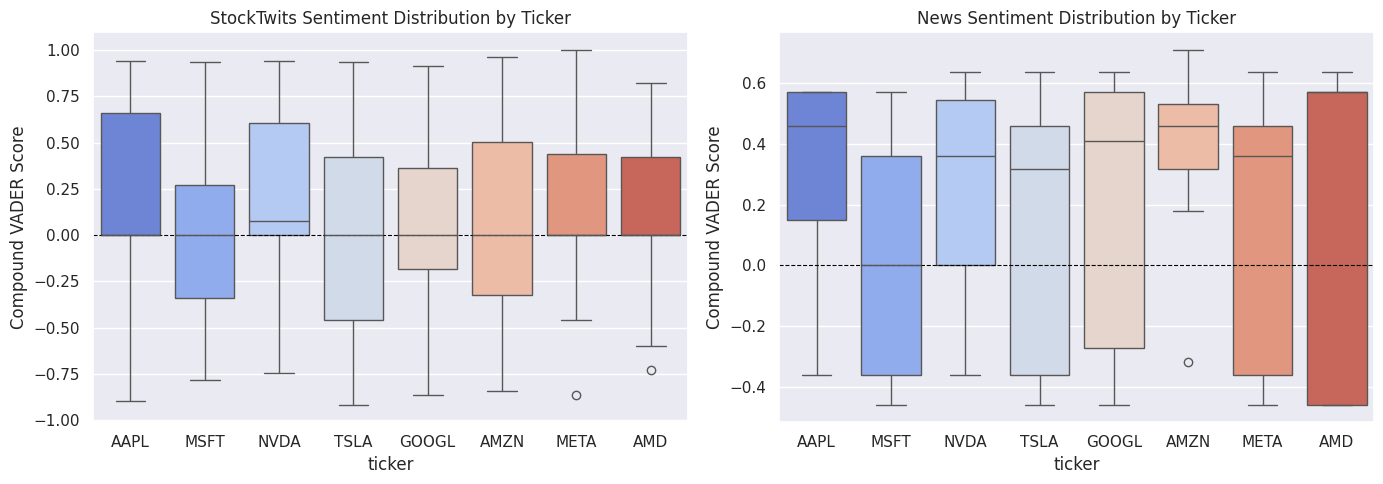

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid", palette="muted")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reddit sentiment distribution by ticker
sns.boxplot(
    data=df_social, x="ticker", y="raw_sentiment",
    order=TICKERS, ax=axes[0], palette="coolwarm"
)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("StockTwits Sentiment Distribution by Ticker")
axes[0].set_ylabel("Compound VADER Score")

# News sentiment distribution by ticker
sns.boxplot(
    data=df_news, x="ticker", y="raw_sentiment",
    order=TICKERS, ax=axes[1], palette="coolwarm"
)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("News Sentiment Distribution by Ticker")
axes[1].set_ylabel("Compound VADER Score")

plt.tight_layout()
plt.show()

## 4. Mention Velocity (Crowd Interest Signal)

In [ ]:
# ── Mention velocity: recent 24h vs prior 6 days ──────────────────────────────
# A rapidly growing mention count is a crowd interest signal independent of
# sentiment direction ("any press is press").

def compute_mention_velocity(df: pd.DataFrame, ts_col: str) -> pd.Series:
    """
    Returns velocity score per ticker:
      velocity = (recent_24h_count / prior_6d_daily_avg) - 1
    Clipped to [-1, 5] to prevent outlier domination.
    """
    df = df.copy()
    df["ts"] = pd.to_datetime(df[ts_col], utc=True)
    cutoff_24h = pd.Timestamp.utcnow() - timedelta(hours=24)
    cutoff_7d  = pd.Timestamp.utcnow() - timedelta(days=7)

    velocities = {}
    for ticker in TICKERS:
        sub       = df[df["ticker"] == ticker]
        recent    = sub[sub["ts"] >= cutoff_24h]
        prior     = sub[(sub["ts"] >= cutoff_7d) & (sub["ts"] < cutoff_24h)]
        daily_avg = len(prior) / 6 if len(prior) > 0 else 1
        v = (len(recent) / daily_avg) - 1
        velocities[ticker] = float(np.clip(v, -1, 5))
    return pd.Series(velocities, name="mention_velocity")


social_velocity = compute_mention_velocity(df_social, "created_utc")
news_velocity   = compute_mention_velocity(df_news, "published_at")
# Combine: weighted average of both sources
mention_velocity = (social_velocity * 0.6 + news_velocity * 0.4).rename("mention_velocity")

print("Mention velocity (higher = growing crowd interest):")
print(mention_velocity.sort_values(ascending=False).to_string())

Mention velocity (higher = growing crowd interest):
META     3.240000
AAPL     2.942857
NVDA     2.866667
MSFT     2.800000
TSLA     2.771429
GOOGL    2.600000
AMZN     2.600000
AMD      2.600000


## 5. Price Momentum Signal

In [ ]:
import yfinance as yf
from scipy import stats as scipy_stats

def fetch_price_signals(tickers: list[str], lookback: int = PRICE_LOOKBACK_DAYS) -> pd.DataFrame:
    """
    Returns per-ticker signals:
      - momentum_20d: 20-day price return
      - momentum_90d: 90-day price return
      - rsi_14:       Relative Strength Index (14-day)
      - vol_ratio:    recent 10d volatility / 30d volatility (regime signal)
    """
    end   = datetime.now()
    start = end - timedelta(days=lookback + 10)  # extra buffer for RSI warmup

    raw = yf.download(
        tickers, start=start.strftime("%Y-%m-%d"),
        end=end.strftime("%Y-%m-%d"), progress=False
    )["Close"]

    results = {}
    for t in tickers:
        try:
            prices = raw[t].dropna()

            # Returns
            mom_20 = (prices.iloc[-1] / prices.iloc[-21] - 1) if len(prices) >= 21 else 0
            mom_90 = (prices.iloc[-1] / prices.iloc[0]  - 1) if len(prices) > 1  else 0

            # RSI-14
            delta  = prices.diff().dropna()
            gains  = delta.clip(lower=0).rolling(14).mean()
            losses = (-delta).clip(lower=0).rolling(14).mean()
            rs     = gains / losses.replace(0, 1e-9)
            rsi    = (100 - 100 / (1 + rs)).iloc[-1]

            # Volatility regime
            log_ret   = np.log(prices / prices.shift(1)).dropna()
            vol_10    = log_ret.iloc[-10:].std() if len(log_ret) >= 10 else np.nan
            vol_30    = log_ret.iloc[-30:].std() if len(log_ret) >= 30 else np.nan
            vol_ratio = (vol_10 / vol_30) if (vol_30 and vol_30 > 0) else 1.0

            results[t] = {
                "momentum_20d": float(mom_20),
                "momentum_90d": float(mom_90),
                "rsi_14":       float(rsi),
                "vol_ratio":    float(vol_ratio),
                "latest_price": float(prices.iloc[-1]),
            }
        except Exception as e:
            print(f"Price fetch error for {t}: {e}")
            results[t] = {"momentum_20d": 0, "momentum_90d": 0, "rsi_14": 50,
                          "vol_ratio": 1.0, "latest_price": np.nan}

    return pd.DataFrame(results).T


print("Fetching price data from Yahoo Finance...")
df_price = fetch_price_signals(TICKERS)
print(df_price.round(4).to_string())

Fetching price data from Yahoo Finance...


/tmp/ipykernel_2374/4267583162.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(


       momentum_20d  momentum_90d   rsi_14  vol_ratio  latest_price
AAPL         0.0702        0.1621  58.2809     1.1168        307.34
MSFT        -0.0076        0.0477  48.0626     1.4351        416.67
NVDA        -0.0291        0.1253  34.3337     1.1086        205.10
TSLA        -0.0505       -0.0305  37.2946     1.1270        391.00
GOOGL       -0.0740        0.2031  30.3519     0.8471        368.53
AMZN        -0.0927        0.1806  35.5697     1.1699        246.03
META        -0.0386       -0.0919  42.7528     1.2366        593.00
AMD          0.1418        1.3481  58.5490     0.9093        466.38


In [ ]:
# ── Normalize momentum to [-1, +1] via rank-based scaling ────────────────────
# Raw % returns differ too much in magnitude across market regimes;
# rank-based normalization keeps the signal ordinal and bounded.

from scipy.stats import rankdata

def rank_normalize(series: pd.Series) -> pd.Series:
    """Convert raw values to percentile rank in [-1, +1]."""
    n = len(series)
    ranks = rankdata(series)  # 1..n
    normalized = (ranks - 1) / max(n - 1, 1) * 2 - 1  # → [-1, +1]
    return pd.Series(normalized, index=series.index)


# Combine 20d and 90d momentum; penalize overbought RSI
df_price["momentum_score"] = (
    rank_normalize(df_price["momentum_20d"]) * 0.5 +
    rank_normalize(df_price["momentum_90d"]) * 0.3 +
    # RSI: 30=oversold(+), 70=overbought(-), center at 50
    rank_normalize(50 - (df_price["rsi_14"] - 50).abs()) * 0.2
)

print("Momentum scores:")
print(df_price["momentum_score"].sort_values(ascending=False).to_string())

Momentum scores:
AMD      0.828571
AAPL     0.485714
MSFT     0.285714
NVDA    -0.114286
META    -0.228571
GOOGL   -0.342857
TSLA    -0.457143
AMZN    -0.457143


## 6. Signal Aggregation & Composite Score

In [ ]:
# ── Aggregate per-ticker sentiment scores ─────────────────────────────────────

def aggregate_sentiment(df: pd.DataFrame) -> pd.Series:
    """
    Volume-weighted mean sentiment per ticker.
    Uses weighted_sentiment so high-engagement posts dominate.
    Then normalizes across tickers to [-1, +1].
    """
    raw = df.groupby("ticker")["weighted_sentiment"].mean().reindex(TICKERS).fillna(0)
    return rank_normalize(raw)


social_sentiment_score = aggregate_sentiment(df_social).rename("social_sentiment")
news_sentiment_score   = aggregate_sentiment(df_news).rename("news_sentiment")
velocity_score         = rank_normalize(mention_velocity).rename("velocity_score")
momentum_score         = df_price["momentum_score"].rename("momentum_score")

# ── Combine into composite ────────────────────────────────────────────────────
df_signals = pd.DataFrame({
    "social_sentiment": social_sentiment_score,
    "news_sentiment":   news_sentiment_score,
    "velocity_score":   velocity_score,
    "momentum_score":   momentum_score,
})

df_signals["composite_score"] = (
    df_signals["social_sentiment"] * W_SOCIAL_SENTIMENT +
    df_signals["news_sentiment"]   * W_NEWS_SENTIMENT   +
    df_signals["velocity_score"]   * W_MENTION_VELOCITY +
    df_signals["momentum_score"]   * W_PRICE_MOMENTUM
)

# Assign signal
def score_to_signal(score: float) -> str:
    if score >= BUY_THRESHOLD:   return "BUY"
    if score <= SELL_THRESHOLD:  return "SELL"
    return "HOLD"


df_signals["signal"]       = df_signals["composite_score"].map(score_to_signal)
df_signals["latest_price"] = df_price["latest_price"]

df_signals = df_signals.sort_values("composite_score", ascending=False)
print(df_signals.round(3).to_string())

       social_sentiment  news_sentiment  velocity_score  momentum_score  composite_score signal  latest_price
AAPL              1.000           0.714           0.714           0.486            0.769    BUY        307.34
NVDA              0.714           0.429           0.429          -0.114            0.420    BUY        205.10
META              0.429          -0.429           1.000          -0.229            0.197   HOLD        593.00
AMZN              0.143           1.000          -0.714          -0.457            0.066   HOLD        246.03
AMD              -0.143          -0.143          -0.714           0.829           -0.063   HOLD        466.38
GOOGL            -0.714           0.143          -0.714          -0.343           -0.426   SELL        368.53
TSLA             -0.429          -0.714          -0.143          -0.457           -0.449   SELL        391.00
MSFT             -1.000          -1.000           0.143           0.286           -0.514   SELL        416.67


## 7. Visualization

In [ ]:
# ── Dashboard: Composite Scores ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Crowd-Informed Investing Model — Signal Dashboard", fontsize=15, fontweight="bold")

signal_colors = {"BUY": "#2ecc71", "HOLD": "#f39c12", "SELL": "#e74c3c"}
bar_colors = [signal_colors[df_signals.loc[t, "signal"]] for t in df_signals.index]

# ① Composite score bar chart
ax = axes[0, 0]
bars = ax.barh(df_signals.index[::-1], df_signals["composite_score"][::-1],
               color=bar_colors[::-1], edgecolor="white", linewidth=0.5)
ax.axvline(BUY_THRESHOLD,  color="#2ecc71", linestyle="--", linewidth=1.2, label=f"Buy  ≥ {BUY_THRESHOLD}")
ax.axvline(SELL_THRESHOLD, color="#e74c3c", linestyle="--", linewidth=1.2, label=f"Sell ≤ {SELL_THRESHOLD}")
ax.axvline(0, color="white", linewidth=0.6)
ax.set_title("Composite Score (↑ = bullish)")
ax.set_xlabel("Score [-1, +1]")
ax.legend(fontsize=8)
for bar, score in zip(bars, df_signals["composite_score"][::-1]):
    ax.text(score + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{score:+.2f}", va="center", fontsize=8)

# ② Heatmap: individual signal components
ax = axes[0, 1]
cols = ["social_sentiment", "news_sentiment", "velocity_score", "momentum_score"]
heatmap_data = df_signals[cols].astype(float)
sns.heatmap(
    heatmap_data, ax=ax, cmap="RdYlGn", center=0,
    vmin=-1, vmax=1, annot=True, fmt=".2f", linewidths=0.4,
    cbar_kws={"label": "Normalized Score"}
)
ax.set_title("Signal Component Heatmap")
ax.set_xticklabels(["StockTwits\nSentiment", "News\nSentiment",
                    "Mention\nVelocity", "Price\nMomentum"], fontsize=8)

# ③ Reddit mention volume by ticker
ax = axes[1, 0]
mention_counts = df_social.groupby("ticker").size().reindex(df_signals.index)
ax.bar(mention_counts.index, mention_counts.values,
       color=[signal_colors[df_signals.loc[t, "signal"]] for t in mention_counts.index],
       edgecolor="white")
ax.set_title("StockTwits Message Volume")
ax.set_ylabel("# Mentions")
ax.set_xlabel("Ticker")

# ④ Signal summary table
ax = axes[1, 1]
ax.axis("off")
table_data = []
for ticker in df_signals.index:
    row = df_signals.loc[ticker]
    table_data.append([
        ticker,
        f"{row['composite_score']:+.3f}",
        row["signal"],
        f"${row['latest_price']:.2f}" if pd.notna(row["latest_price"]) else "N/A",
    ])
tbl = ax.table(
    cellText=table_data,
    colLabels=["Ticker", "Score", "Signal", "Price"],
    cellLoc="center", loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.6)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2c3e50")
        cell.set_text_props(color="white", fontweight="bold")
    elif col == 2 and row > 0:
        sig = table_data[row - 1][2]
        cell.set_facecolor(signal_colors[sig] + "55")  # alpha
ax.set_title("Investment Signals", fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig("crowd_investing_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved to crowd_investing_dashboard.png")

## 8. Historical Evaluation

Three complementary tests using **Google Trends** as a real historical crowd-sentiment proxy
(academic precedent: Da, Engelberg & Gao 2011 — *In Search of Attention*):

1. **Information Coefficient (IC)** — weekly correlation between signal rank and forward return
2. **Quintile Analysis** — cumulative return of top-2 vs bottom-2 tickers by signal score
3. **Hit Rate** — % of weeks where the highest-signal ticker beats the lowest-signal ticker

In [ ]:
from pytrends.request import TrendReq
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from scipy.stats import spearmanr, ttest_1samp
import warnings
warnings.filterwarnings('ignore')

print("Fetching 2-year weekly price history...")
end   = datetime.now()
start = end - timedelta(days=730)
prices = yf.download(
    TICKERS,
    start=start.strftime('%Y-%m-%d'),
    end=end.strftime('%Y-%m-%d'),
    interval='1wk', progress=False
)['Close'].ffill().dropna()
print(f'  Price history: {prices.shape[0]} weeks x {prices.shape[1]} tickers')

print("Fetching Google Trends (crowd interest proxy)...")
pytrends = TrendReq(hl='en-US', tz=0, timeout=(10, 30), retries=3, backoff_factor=0.5)

trends_frames = []
# Fetch in batches of 5 (Google Trends limit per request)
for i in range(0, len(TICKERS), 5):
    batch = [f'{t} stock' for t in TICKERS[i:i+5]]
    try:
        pytrends.build_payload(
            batch,
            timeframe=f"{start.strftime('%Y-%m-%d')} {end.strftime('%Y-%m-%d')}",
            geo='US',
        )
        df_t = pytrends.interest_over_time()
        if 'isPartial' in df_t.columns:
            df_t = df_t.drop(columns=['isPartial'])
        df_t.columns = [c.replace(' stock', '') for c in df_t.columns]
        trends_frames.append(df_t)
    except Exception as e:
        print(f'  Trends error batch {i}: {e}')

trends_raw = pd.concat(trends_frames, axis=1).reindex(columns=TICKERS)
# Resample to weekly to align with prices
trends_weekly = trends_raw.resample('W').mean()
print(f'  Trends history: {trends_weekly.shape[0]} weeks x {trends_weekly.shape[1]} tickers')

# Align both to same date range
common_idx   = prices.index.intersection(trends_weekly.index)
prices_w     = prices.loc[common_idx]
trends_w     = trends_weekly.loc[common_idx]
weekly_ret   = prices_w.pct_change().shift(-1)  # NEXT week's return (forward-looking)
print(f'  Aligned weeks: {len(common_idx)}')

In [ ]:
# ── Build historical composite signal ───────────────────────────────────────
# For each week, we compute:
#   - Trends velocity:  % change in search interest vs 4-week average
#   - Price momentum:   4-week trailing return (lagged, so no lookahead)
#   - Composite signal: weighted combination, then cross-sectional rank-normalised

from scipy.stats import rankdata

def rank_norm_row(row):
    """Rank-normalise a single row to [-1, +1]."""
    n = len(row)
    ranks = rankdata(row.fillna(0))
    return pd.Series((ranks - 1) / max(n - 1, 1) * 2 - 1, index=row.index)

# Trends velocity: z-score of current week vs rolling 4-week mean
trends_vel = (
    (trends_w - trends_w.rolling(4).mean()) /
    (trends_w.rolling(4).std().replace(0, 1))
).clip(-3, 3)

# Price momentum: 4-week trailing return (known at signal time)
price_mom = prices_w.pct_change(4)

# Composite: 60% trends velocity + 40% price momentum, row-wise rank-normalised
composite = pd.DataFrame(index=common_idx, columns=TICKERS, dtype=float)
for date in common_idx:
    vel_row = trends_vel.loc[date]
    mom_row = price_mom.loc[date]
    raw     = vel_row * 0.6 + mom_row * 0.4
    composite.loc[date] = rank_norm_row(raw)

# Drop weeks with insufficient history
composite = composite.dropna()
fwd_ret   = weekly_ret.loc[composite.index]

print(f'Signal history: {len(composite)} usable weeks')
composite.tail(3).round(2)

In [ ]:
# ── 1. Information Coefficient (IC) ─────────────────────────────────────────
# Spearman rank correlation between signal score and next-week return each week.
# IC > 0 means the signal has directional predictive value.
# ICIR (IC / std(IC)) > 0.5 is considered investable in quant finance.

ics = []
for date in composite.index:
    sig = composite.loc[date]
    ret = fwd_ret.loc[date]
    valid = sig.notna() & ret.notna()
    if valid.sum() >= 4:
        ic, _ = spearmanr(sig[valid], ret[valid])
        ics.append({'date': date, 'ic': ic})

df_ic  = pd.DataFrame(ics).set_index('date')
mean_ic = df_ic['ic'].mean()
icir    = df_ic['ic'].mean() / df_ic['ic'].std()
t_stat, p_val = ttest_1samp(df_ic['ic'].dropna(), 0)

print(f'Mean IC:  {mean_ic:+.4f}  (>0 = signal has predictive value)')
print(f'ICIR:     {icir:+.4f}  (>0.5 = considered investable)')
print(f't-stat:   {t_stat:+.4f}  p-value: {p_val:.4f}  (< 0.05 = statistically significant)')
print(f'IC > 0:   {(df_ic["ic"] > 0).mean():.1%} of weeks')

# ── 2. Quintile (Top-2 vs Bottom-2) Analysis ─────────────────────────────────
top_ret  = []
bot_ret  = []
dates_q  = []

for date in composite.index:
    sig = composite.loc[date]
    ret = fwd_ret.loc[date].dropna()
    if len(ret) < 4:
        continue
    top2 = sig.nlargest(2).index
    bot2 = sig.nsmallest(2).index
    top_ret.append(ret[top2].mean())
    bot_ret.append(ret[bot2].mean())
    dates_q.append(date)

df_q = pd.DataFrame({'top2': top_ret, 'bot2': bot_ret}, index=dates_q)
df_q['spread'] = df_q['top2'] - df_q['bot2']

cum_top  = (1 + df_q['top2']).cumprod()
cum_bot  = (1 + df_q['bot2']).cumprod()
cum_ew   = (1 + (df_q['top2'] + df_q['bot2']) / 2).cumprod()  # equal-weight

print(f'\nTop-2 total return:    {cum_top.iloc[-1]-1:+.1%}')
print(f'Bottom-2 total return: {cum_bot.iloc[-1]-1:+.1%}')
print(f'Spread (annualised):   {df_q["spread"].mean() * 52:+.1%}')

# ── 3. Hit Rate ───────────────────────────────────────────────────────────────
# Did the top-ranked ticker beat the bottom-ranked ticker the following week?
hit_weeks = 0
total_weeks = 0
for date in composite.index:
    sig = composite.loc[date]
    ret = fwd_ret.loc[date].dropna()
    if len(ret) < 2:
        continue
    top1 = sig.idxmax()
    bot1 = sig.idxmin()
    if top1 in ret.index and bot1 in ret.index:
        if ret[top1] > ret[bot1]:
            hit_weeks += 1
        total_weeks += 1

hit_rate = hit_weeks / total_weeks if total_weeks else 0
print(f'\nHit rate: {hit_rate:.1%}  ({hit_weeks}/{total_weeks} weeks top-ranked beat bottom-ranked)')
print(f'Random baseline: 50.0%')

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style='darkgrid')
fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ① Rolling IC over time
ax1 = fig.add_subplot(gs[0, :])
roll_ic = df_ic['ic'].rolling(8).mean()
ax1.bar(df_ic.index, df_ic['ic'],
        color=['#2ecc71' if x > 0 else '#e74c3c' for x in df_ic['ic']],
        alpha=0.4, width=5, label='Weekly IC')
ax1.plot(roll_ic.index, roll_ic.values,
         color='white', linewidth=2, label='8-week rolling avg')
ax1.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax1.axhline(mean_ic, color='#3498db', linewidth=1.5,
            linestyle=':', label=f'Mean IC = {mean_ic:+.3f}')
ax1.set_title('Information Coefficient Over Time  (signal vs next-week return)', fontsize=12)
ax1.set_ylabel('Spearman IC')
ax1.legend(fontsize=9)

# ② Quintile cumulative returns
ax2 = fig.add_subplot(gs[1, :])
ax2.plot(cum_top.index,  cum_top.values,  color='#2ecc71',  linewidth=2, label='Top-2 tickers by signal')
ax2.plot(cum_bot.index,  cum_bot.values,  color='#e74c3c',  linewidth=2, label='Bottom-2 tickers by signal')
ax2.plot(cum_ew.index,   cum_ew.values,   color='#95a5a6',  linewidth=1.5, linestyle='--', label='Equal-weight (all 4)')
ax2.fill_between(cum_top.index, cum_top.values, cum_bot.values, alpha=0.08, color='#2ecc71')
ax2.axhline(1.0, color='white', linewidth=0.5)
ax2.set_title('Quintile Analysis: Top-2 vs Bottom-2 Tickers by Composite Signal', fontsize=12)
ax2.set_ylabel('Cumulative Return (start = 1.0)')
ax2.legend(fontsize=9)

# ③ IC distribution
ax3 = fig.add_subplot(gs[2, 0])
ax3.hist(df_ic['ic'].dropna(), bins=25,
         color='#3498db', edgecolor='white', alpha=0.8)
ax3.axvline(0,       color='grey',    linewidth=1, linestyle='--')
ax3.axvline(mean_ic, color='#2ecc71', linewidth=2, linestyle='-',
            label=f'Mean = {mean_ic:+.3f}')
ax3.set_title('IC Distribution')
ax3.set_xlabel('Spearman IC')
ax3.set_ylabel('Frequency')
ax3.legend(fontsize=9)

# ④ Summary stats table
ax4 = fig.add_subplot(gs[2, 1])
ax4.axis('off')
rows = [
    ['Mean IC',              f'{mean_ic:+.4f}'],
    ['ICIR',                 f'{icir:+.4f}'],
    ['p-value',              f'{p_val:.4f}'],
    ['IC > 0',               f'{(df_ic["ic"]>0).mean():.1%}'],
    ['Top-2 total return',   f'{cum_top.iloc[-1]-1:+.1%}'],
    ['Bottom-2 total return',f'{cum_bot.iloc[-1]-1:+.1%}'],
    ['Spread (annualised)',  f'{df_q["spread"].mean()*52:+.1%}'],
    ['Hit rate',             f'{hit_rate:.1%}'],
    ['Random baseline',      '50.0%'],
]
tbl = ax4.table(cellText=rows, colLabels=['Metric', 'Value'],
                cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.8)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif c == 1:
        val_str = rows[r-1][1] if r > 0 else ''
        try:
            val = float(val_str.replace('%','').replace('+',''))
            cell.set_facecolor('#2ecc7133' if val > 0 else '#e74c3c33')
        except:
            pass
ax4.set_title('Evaluation Summary', fontweight='bold', pad=15)

plt.savefig('crowd_investing_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Evaluation chart saved to crowd_investing_evaluation.png')

## 9. Final Recommendations

In [ ]:
# ── Print final investment signals ────────────────────────────────────────────
print("=" * 60)
print(f"  CROWD-INFORMED INVESTING MODEL — {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print("=" * 60)
print(f"{'Ticker':<8} {'Score':>8} {'Signal':<7} {'Social':>9} {'News':>9} {'Velocity':>10} {'Momentum':>10}")
print("-" * 65)

for ticker in df_signals.index:
    r = df_signals.loc[ticker]
    sig_color = {"BUY": "\033[92m", "HOLD": "\033[93m", "SELL": "\033[91m"}
    reset = "\033[0m"
    color = sig_color.get(r["signal"], "")
    print(
        f"{ticker:<8} {r['composite_score']:>+8.3f} "
        f"{color}{r['signal']:<7}{reset} "
        f"{r['social_sentiment']:>+9.3f} "
        f"{r['news_sentiment']:>+9.3f} "
        f"{r['velocity_score']:>+10.3f} "
        f"{r['momentum_score']:>+10.3f}"
    )

print("=" * 60)
print("\nNOTE: This model is for research and educational purposes only.")
print("Past performance does not guarantee future results.")
print("Always conduct independent due diligence before investing.")

## 10. Next Steps & Extensions

| Extension | Description |
|-----------|-------------|
| **StockTwits auth** | Register a free app at stocktwits.com/developers for higher rate limits |
| **More tickers** | Expand `TICKERS` list — StockTwits supports any symbol |
| **FinBERT sentiment** | Replace VADER with `ProsusAI/finbert` for higher accuracy on financial text |
| **NewsAPI live** | Set `NEWSAPI_KEY` env var to pull real headlines instead of demo data |
| **Options flow** | Integrate unusual options activity (Unusual Whales API) as a contrarian signal |
| **Short interest** | Finra short volume data as a crowded-short indicator |
| **Earnings calendar** | Suppress signals near earnings dates to avoid event risk |
| **Portfolio optimizer** | Replace equal-weight long/short with mean-variance optimization (cvxpy) |
| **Alerting** | Schedule notebook to run daily and send Slack/email alerts on BUY/SELL signals |
| **Factor attribution** | Regress returns on Fama-French 5 factors to isolate alpha from crowd sentiment |
